# A model for Nepal

This chapter builds a small macroeconomic model from data and then uses it. It shows how
to declare identities, how to estimate behavioural equations, how to join these and the
data into a model object, what add factors are and how to initialize them, and finally how
to run an experiment against the resulting baseline.

The model is a system of equations of two kinds: **behavioural equations**, estimated from
data and holding only up to an error, and **identities**, which hold exactly.

The estimation syntax used along the way — coefficient placeholders, the `ST.` constraint
clause, the estimation tags — is documented in the *Estimation* chapter of the
*ModelFlow - Model Specification* supplement. Here it is simply used.

## Initialize the python session

First the Python session is initialized. This notebook assumes that a `ModelFlow`
environment has been installed and created; see Burns and Hansen (2025) for instructions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modelclass import model                  # the ModelFlow model object
import modeljupytermagic                       # %%dataframe and %%Makemymodel magic cells
from modelestimator_new import Estimate_nls    # estimation of econometric equations

## Data preparation

A first step in any model build exercise is to load data. Typically it is pulled from a
variety of sources: the national income accounts; the balance of payments; government
accounts; and additional sources such as the growth and import demand of trading partners.

Here the data is entered directly in a Jupyter cell with `%%dataframe`, which is defined by
the `import modeljupytermagic` line above. In a more complete example the data would be
assembled from the sources just listed.

The data is from a World Bank model for Nepal.

### Load data

To estimate and simulate models the data has to be in a Pandas dataframe. So that this
notebook is self-contained it is loaded in the next cell. Pandas allows many ways of
wrangling data, so any available data can be onboarded.

Two things about the range are deliberate. The first row, 2010, carries GDP and investment
but nothing else — which is what an equation with a lag needs at the start of the sample,
and no more. And the table runs past the last observed year: 2010–2024 is history,
2025–2030 a forecast. That forecast is not decoration. A model is normally used to ask what
a shock does *relative to an existing projection*, so the projection has to be in the data
before any experiment can be run against it.

In [3]:
%%dataframe df start=2010 show
           Y     CON    GOV     INV    EXP     IMP
2010 1507633     nan    nan  376664    nan     nan
2011 1559222 1320302 127814  373939 121715  444232
2012 1632040 1360376 128860  381170 146293  457746
2013 1689572 1396402 124255  414557 165235  522448
2014 1791141 1438904 138533  466473 194706  632208
2015 1862357 1476067 154467  536417 199215  692795
2016 1870424 1537410 135991  570679 164739  714626
2017 2038337 1549515 165119  702408 179327  916470
2018 2193706 1645118 168507  785371 193125 1090956
2019 2339743 1779022 184955  874481 203831 1154398
2020 2284300 1842997 192011  796389 171458  913728
2021 2394818 1989827 188832  874412 134904 1085637
2022 2529243 2125755 207023  907774 180852 1249408
2023 2576251 2144255 202054  809228 190884 1034756
2024 2737770 2187140 213861  847178 223748  998743
2025 2873409 2311319 229992  896806 258987 1088281
2026 3044418 2469903 247718  970059 284928 1192775
2027 3247138 2644779 265841 1060412 309374 1297854
2028 3469278 2825068 283920 1161461 332639 1398396
2029 3692901 2999393 301261 1265387 355073 1492799
2030 3905964 3161294 317423 1366512 376928 1580778

,Y,CON,GOV,INV,EXP,IMP
index,,,,,,
2010,1507633.0,NaN,NaN,376664.0,NaN,NaN
2011,1559222.0,1320302.0,127814.0,373939.0,121715.0,444232.0
2012,1632040.0,1360376.0,128860.0,381170.0,146293.0,457746.0
2013,1689572.0,1396402.0,124255.0,414557.0,165235.0,522448.0
2014,1791141.0,1438904.0,138533.0,466473.0,194706.0,632208.0
2015,1862357.0,1476067.0,154467.0,536417.0,199215.0,692795.0
2016,1870424.0,1537410.0,135991.0,570679.0,164739.0,714626.0
2017,2038337.0,1549515.0,165119.0,702408.0,179327.0,916470.0
2018,2193706.0,1645118.0,168507.0,785371.0,193125.0,1090956.0


### Generate additional series

Estimation needs a few derived series, calculated in the next cell.

`YDISC` is the statistical discrepancy — what is left of GDP once the expenditure
components are subtracted. It matters because the GDP identity has to hold *exactly* for
the model to reproduce the data. `GDE` is domestic demand, which the import equation uses.

In [4]:
npl = df.mfcalc('''
ydisc=y-(con+inv+gov+eXp-imp)
gde=(con+gov+inv)
''')
npl.index = npl.index.year
npl

,Y,CON,GOV,INV,EXP,IMP,YDISC,GDE
index,,,,,,,,
2010,1507633.0,NaN,NaN,376664.0,NaN,NaN,NaN,NaN
2011,1559222.0,1320302.0,127814.0,373939.0,121715.0,444232.0,59684.0,1822055.0
2012,1632040.0,1360376.0,128860.0,381170.0,146293.0,457746.0,73087.0,1870406.0
2013,1689572.0,1396402.0,124255.0,414557.0,165235.0,522448.0,111571.0,1935214.0
2014,1791141.0,1438904.0,138533.0,466473.0,194706.0,632208.0,184733.0,2043910.0
2015,1862357.0,1476067.0,154467.0,536417.0,199215.0,692795.0,188986.0,2166951.0
2016,1870424.0,1537410.0,135991.0,570679.0,164739.0,714626.0,176231.0,2244080.0
2017,2038337.0,1549515.0,165119.0,702408.0,179327.0,916470.0,358438.0,2417042.0
2018,2193706.0,1645118.0,168507.0,785371.0,193125.0,1090956.0,492541.0,2598996.0


### Save the data for later use

The data is written to a **parquet** file: a compressed columnar format which preserves
column types and the index, and is fast to read back. Anything built later — a script
version of this model, a separate scenario notebook — can pick the data up from there
rather than re-deriving it.

In [5]:
from pathlib import Path

Path('data').mkdir(exist_ok=True)
npl.to_parquet('data/npl.parquet')

### Give the variables English names

Variable descriptions make the estimation and simulation output easier to read. They are
supplied as a dictionary and carried by the estimator and the model.

In [6]:
var_description= {
'Y':'GDP',
'CON':'Private Consumption', 
'GOV':'Government', 
'INV':'Investment',
'EXP':'Exports', 
'IMP':'Imports', 
'YDISC':'Statistical Discrepancy',
'GDE':'Domestic Demand',
    
}

## A default estimation method

Every equation below is estimated on the same data, over the same sample, with the same
coefficient names. `.with_defaults()` collects those once and returns a callable — named
`ls` — which constructs and runs an estimation for any equation it is given. Any keyword
passed to the callable, or any equation tag, overrides a stored default.

The sample stops in **2019** deliberately: covid makes 2020 and 2021 unlike anything these
equations could explain, and fitting through them would carry that into every simulation.
The later years stay in the data and are used when add factors are calculated.

`param_names` is what allows coefficients to be called `LAMBDA` and `BETA_LONGTERM` rather
than `C(1)` and `C(2)`. It is worth the small effort — a named coefficient is checked
against economic sense more easily than a numbered slot.

In [7]:
ls = Estimate_nls.with_defaults(
    smpl=(2011, 2019),#estimate our equation over the short! pre-covid period
    var_description=var_description,
    input_df=npl, #npl is the name of the dataframe that we created above.
    param_names=['lambda', 'beta_shortterm', 'beta_longterm'],

)

##  Equations

A model is a collection of identities and behavioural equations, so those have to be
created first.

:::{admonition} Box: Estimating equations
:class: tip

1. Always start with theory
    - Not a good idea to blindly smash variables together (spurious regressions,
      statistical biases). The end goal is *economic insight*, not statistical fit.
    - Use economic theory as the basis for the long-run component of behavioural equations,
      and the macroeconomic framework for accounting and quasi-identities. Theory and the
      literature are also used to evaluate the coefficients. Short-run components can be
      more ad hoc, and reflect how economies actually work rather than what textbooks say
      they will.
2. Collect, import and transform data
    - Ensure accounting consistency: base year, units, currency, identities.
3. Estimate individual equations
    - Functional form: ideally the dynamics are modelled, not just the levels.
    - Evaluate the estimated coefficients, goodness of fit, residuals and outliers for each
      equation.
    - Impose restrictions from theory where necessary — an ECM coefficient in absolute
      value between 0.2 and 0.8, for instance.
4. Solve the model.
5. Test the model properties and revise the equations
    - Baseline solution consistency and stability (convergence).
    - Shocks return expected results (simulation properties).
6. Repeat 1–5 as new data and model extensions arrive
    - No one model rules them all.
    - Be extra vigilant with models estimated on short time series.
:::

### Private consumption

The first equation to estimate is consumption.

**Theory.** Standard macroeconomics makes consumption a function of income; here GDP ($y$)
proxies for income. Short-run and long-run determinants can be distinguished.

**Long run.** The permanent income hypothesis says that in the long run individuals consume
a constant share of their disposable income, the share — the marginal propensity to
consume — being determined by their preferences:

$ C_t = \alpha \cdot Y_t^{\beta^{longterm}_1} + \eta_t $

or in logarithms, where lower-case letters denote the natural logarithm of their upper-case
equivalents:

$ c_t = \alpha + \beta^{longterm}_1 \cdot y_t + \zeta_t $

**Short run.** In the short run consumption deviates from its long-run path, through
identified or random events. Here the growth of consumption responds to the growth of
income:

$ \Delta c_t = \beta^{shortterm}_{10} \cdot \Delta y_t + \epsilon_t $

**Estimation: the ECM.** Lagging the long-run equation, expressing it in logarithms and
combining it with the short-run equation gives a non-linear error correction equation,
following Wickens and Breusch (1988), which can be estimated by non-linear least squares:

$ \Delta c_t = - \lambda \,(c_{t-1} - y_{t-1} - \log \beta^{longterm}_1) +
\beta^{shortterm}_{10}\, \Delta y_t + \epsilon_t $

$\beta^{longterm}_1$ is the long-run share of consumption in income and
$\beta^{shortterm}_{10}$ the short-run elasticity of consumption with respect to income;
as written, the long-run elasticity is constrained to one. $\lambda$ is the speed of
adjustment: the fraction of any gap to the long-run level that is closed each year.

In [8]:
%%Makemymodel Mtoymodel segment=consumption render_est=False render=False

## The consumption function

The equation as estimated — nothing imposed, all three coefficients from the data:

><stoc,estimator=ls,caption='Consumption, unconstrained'> dlog(con)= -lambda*(log(con(-1))-log(y(-1))-log(abs(beta_longterm(1))))+beta_shortterm(10)*dlog(y)

A speed of adjustment can also be imposed rather than estimated, and there are two ways to
do it. Write the number into the equation:

><stoc,drop,estimator=ls,caption='Consumption, lambda written in as 0.3'> dlog(con)= -0.3*(log(con(-1))-log(y(-1))-log(abs(beta_longterm(1))))+
>> beta_shortterm(10)*dlog(y)

or leave the coefficient in place and constrain it with an `ST.` clause, which keeps the
equation readable and reports the coefficient as fixed rather than hiding it in the
arithmetic:

><stoc,drop,estimator=ls,caption='Consumption, lambda constrained to 0.3'> dlog(con)= -lambda*(log(con(-1))-log(y(-1))-log(abs(beta_longterm(1))))+beta_shortterm(10)*dlog(y) st. lambda=0.3

In [9]:
%%Makemymodel test render_est=True render=False

### Keeping a coefficient positive

The long-run coefficient sits inside a logarithm, so the estimator has to be kept away from
negative values of it. Every equation above does that by wrapping it in `abs()`.

The alternative is to drop the `abs()` and constrain the coefficient itself. That says the
same thing to a reader and rather more to the minimizer: a bound is enforced throughout the
search, whereas `abs()` lets the search wander to a negative value and folds it back,
reporting a coefficient whose sign carries no meaning.

Two constraints are given below, separated by `;` — the speed of adjustment fixed at 0.3,
and the long-run coefficient held non-negative. Note also the `>>` at the start of the last
line: it continues the equation from the line before, which keeps a long specification
readable.

This one is built as a model of its own, `test`, because it is an illustration rather than
part of the toy model.

><stoc,estimator=ls,caption='Consumption, lambda fixed and beta_longterm kept positive'> dlog(con)= -lambda*(log(con(-1))-log(y(-1))-log(beta_longterm(1)))
>> +beta_shortterm(10)*dlog(y) st. lambda=0.3 ; beta_longterm(1) >=0

Item,Value
Estimator,ls
Effective sample,"(np.int64(2012), np.int64(2019))"
Original equation,DLOG(CON)= -LAMBDA(LOG(CON(-1))-LOG(Y(-1))-LOG(BETA_LONGTERM(1))) +BETA_SHORTTERM(10)DLOG(Y) ST. LAMBDA=0.3 ; BETA_LONGTERM(1) >=0
Estimated equation,DLOG(CON)= -(0.3000000000)(LOG(CON(-1))-LOG(Y(-1))-LOG((0.9182775481))) +(-0.0535080127)DLOG(Y)
success,True
message,gtol termination condition is satisfied.
chisqr,0.001156974133
redchi,0.0001928290222
aic,-66.73110984
bic,-66.57222675


In [10]:
%%Makemymodel Mtoymodel segment=Government
## Government expenditure

The same error correction form as consumption. Estimated without restrictions the speed of
adjustment comes out above one, which means the equation overcorrects — it would overshoot
its long-run level and oscillate back rather than converge onto it:

><stoc,drop,estimator=ls,caption='Government, unconstrained'> dlog(gov)=-lambda*(log(gov(-1))-log(y(-1))-log(abs(beta_longterm(1)))) + beta_shortterm(10)*dlog(y)

So 0.5 is imposed instead, implying that half of any gap closes each year and the equation
returns to equilibrium within about two years:

><stoc,estimator=ls,caption='Government, lambda imposed at 0.5'> dlog(gov)=-0.5*(log(gov(-1))-log(y(-1))-log(abs(beta_longterm(1)))) + beta_shortterm(10)*dlog(y)

Item,Value
Estimator,ls
Effective sample,"(np.int64(2012), np.int64(2019))"
Original equation,DLOG(GOV)=-LAMBDA(LOG(GOV(-1))-LOG(Y(-1))-LOG(ABS(BETA_LONGTERM(1)))) + BETA_SHORTTERM(10)DLOG(Y)
Estimated equation,DLOG(GOV)=-(1.2457148604)(LOG(GOV(-1))-LOG(Y(-1))-LOG(ABS((0.0756258858)))) + (1.6947092960)DLOG(Y)
success,True
message,gtol termination condition is satisfied.
chisqr,0.009063251913
redchi,0.001812650383
aic,-48.26375067
bic,-48.02542605


In [11]:
%%Makemymodel Mtoymodel segment=Investment
## Investment

Investment is made a function of GDP less government spending — on the strong assumption
that government spending crowds out investment one for one. The speed of adjustment is
imposed at 0.2, since estimating it freely gives an implausibly slow adjustment:

><stoc,estimator=ls,caption='Investment, lambda imposed at 0.2'> dlog(inv)=-.2*(log(inv(-1))-log(y(-1)-gov(-1))-log(abs(beta_longterm(1))))+beta_shortterm(10)*dlog(y-gov)

Item,Value
Estimator,ls
Effective sample,"(np.int64(2012), np.int64(2019))"
Original equation,DLOG(INV)=-.2(LOG(INV(-1))-LOG(Y(-1)-GOV(-1))-LOG(ABS(BETA_LONGTERM(1))))+BETA_SHORTTERM(10)DLOG(Y-GOV)
Estimated equation,DLOG(INV)=-.2(LOG(INV(-1))-LOG(Y(-1)-GOV(-1))-LOG(ABS((0.3059181766))))+(2.0621068876)DLOG(Y-GOV)
success,True
message,gtol termination condition is satisfied.
chisqr,0.02393097397
redchi,0.003988495662
aic,-42.49618575
bic,-42.33730267


In [12]:
%%Makemymodel Mtoymodel segment=Imports
## Imports

Imports respond to domestic demand — private and government consumption plus investment,
which is `GDE`, derived above. Two restrictions are imposed: a speed of adjustment of 0.2,
and a unit short-run elasticity, so that a one per cent rise in domestic demand raises
imports by one per cent on impact:

><stoc,estimator=ls,caption='Imports, lambda 0.2 and unit elasticity'> dlog(imp)=-0.2*(log(imp(-1))-log(gde(-1))-log(abs(beta_longterm(1))))+1.*dlog(gde)

Item,Value
Estimator,ls
Effective sample,"(np.int64(2012), np.int64(2019))"
Original equation,DLOG(IMP)=-0.2(LOG(IMP(-1))-LOG(GDE(-1))-LOG(ABS(BETA_LONGTERM(1))))+1.DLOG(GDE)
Estimated equation,DLOG(IMP)=-0.2(LOG(IMP(-1))-LOG(GDE(-1))-LOG(ABS((0.4239118898))))+1.DLOG(GDE)
success,True
message,gtol termination condition is satisfied.
chisqr,0.03938784452
redchi,0.005626834932
aic,-40.50991653
bic,-40.43047499


In [13]:
%%Makemymodel Mtoymodel segment=identities


## GDP definition

This is an identity. So no estimation here 
> <ident> y=con+inv+gov+exp-imp+ydisc

## Domestic demand

This is also en identity.
> <ident> gde=con+inv+gov

## GDP definition

This is an identity. So no estimation here 
```text
> <ident> y=con+inv+gov+exp-imp+ydisc
```

## Domestic demand

This is also en identity.
```text
> <ident> gde=con+inv+gov
```

## Combining the segments

A final call *without* `segment=` combines everything written above into one `Makemodel`
instance, `Mtoymodel`, holding the documentation, the equations, the estimation results and
the generated model additions.

In [14]:
%Makemymodel Mtoymodel render=False render_est=False

### The causality structure

The dependency graph shows which variable is determined by which. Exogenous variables are
yellow, endogenous blue.

No minimum feedback order: `k` must be an integer satisfying `0 < k < min(A.shape)`. 


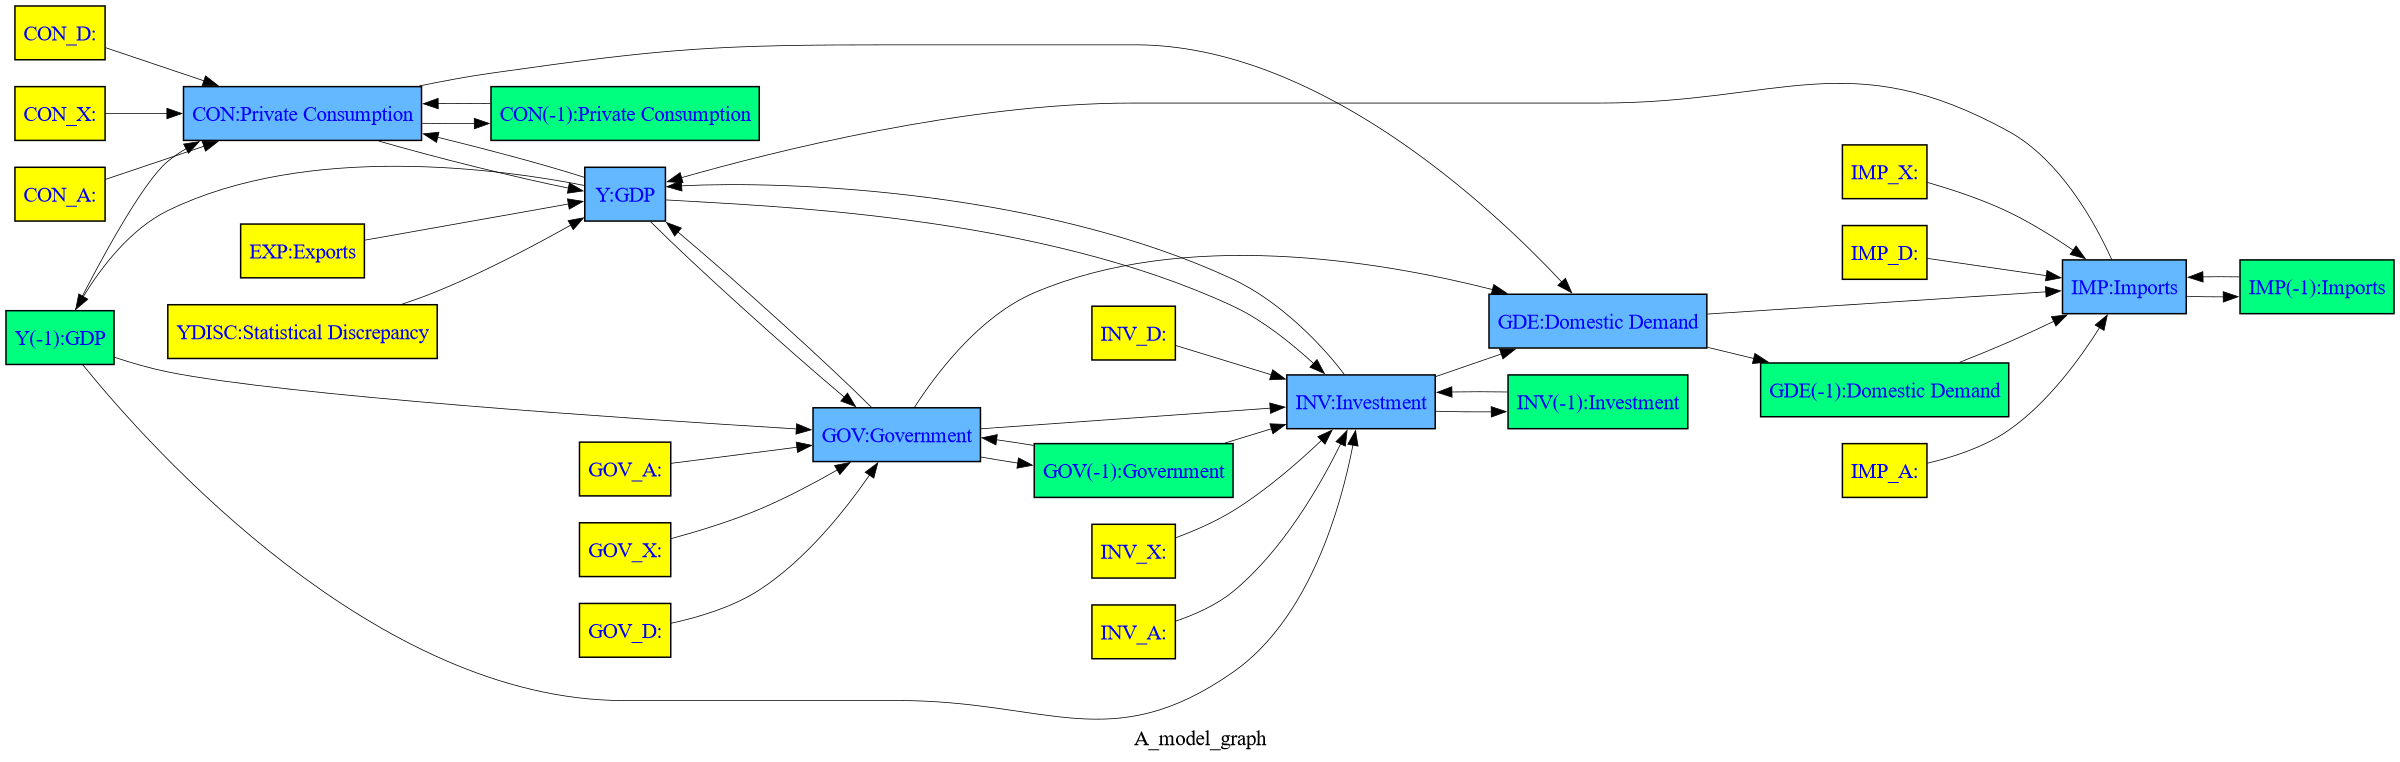

In [15]:
Mtoymodel.mmodel.drawmodel(png=1, size=(8, 8))

### An HTML report on the estimation can be created and opened

In [16]:
Mtoymodel.report().show()  

### Extracting the model

The solvable model is a property of `Mtoymodel`.

Note the effect of `<drop>` above: the alternative specifications of consumption and
government are still estimated, and their results still appear in the documentation, but
they are not emitted as equations. Without it each endogenous variable would be defined
more than once, the last definition would silently win, and the model would depend on the
order the cells happened to run in.

In [17]:
toymodel = Mtoymodel.mmodel

At this stage the model exists as a system of equations, but we have not connected it to the data on which the equations will operate (although we have generated the data above when we created the `DataFrame` `npl`.



## Add factors

Add factors are one of the most important features of a macro-structural model, and the
feature that makes it a flexible tool for both model-assisted, judgment-based forecasting
and model-based simulation.

An essential property of any model is that it can reproduce history — that given the same
inputs it returns the same results. The identities of a `ModelFlow` model always hold, but
an estimated equation does so only if its error term is included.

Recall for a simple regression

$$ y_t = \alpha + \beta X_t + \eta_t $$

that the estimated equation is written

$$ y_t = \hat{\alpha} + \hat{\beta} X_t + \hat{\eta}_t $$

Writing the fitted value of the equation as $\hat{y}_t = \hat{\alpha} + \hat{\beta} X_t$,
the same thing reads

$$ y_t = \hat{y}_t + \hat{\eta}_t \qquad\text{or}\qquad y_t - \hat{y}_t = \hat{\eta}_t $$

Over the historical period this is an identity and always true, for given $\alpha$, $\beta$,
$X$ and $y$. Econometrically $\eta_t$ is the error term — but in the forecast period there
is no ex ante error, so in the general case it is called the **add factor**: the number
added to the fitted value of the equation to arrive at the historical value, or in the
forecast period at the forecast value.

Since the expected value of $\eta_t$ in the forecast period is zero, a non-zero add factor
there measures the extent to which the forecast departs from its econometric expectation —
the amount that has to be added for the equation to hold. Hence *add factor*:

$$ AF_t \equiv y_t - \hat{y}_t $$

Without its add factor the `GOV` equation — or any other behavioural equation — cannot
reproduce history. In the graph in the HTML report the residual is exactly this: the
difference between the fitted and the actual value of `GOV`.

Setting the add factors equal to the difference between fitted and actual results makes the
model reproduce history. The call is

```python
Mtoymodel.init_addfactors(npl, 2016, 2024, show=True, check=True, multiplier=1_000)
```

which calculates, for every behavioural equation, the add factors that satisfy the identity
above.

- `npl` — the dataframe holding every value the model needs
- `2016, 2024` — the period the add factors are calculated over, here the historical period
- `show=True` — display the calculated add factors
- `check=True` — solve the model on the result and report whether it really is aligned
- `multiplier=1_000` — scale the reported differences, so that very small numbers are
  readable rather than a column of zeros

The method returns a copy of the input dataframe with an `_A` variable added for each
behavioural equation, equal to the difference between the data and the fitted value of the
equation. Over the historical period these are the error terms of the econometric
equations.

In [18]:
baseline = Mtoymodel.init_addfactors(npl,2016,2024,show=True,check=True,multiplier=1_000)



Add factors to align historic values and model results
          CON_A     GOV_A     IMP_A     INV_A
index                                        
2016  -0.007206 -0.023351 -0.060372  0.035381
2017  -0.016078  0.021094  0.117309  0.063518
2018   0.000229 -0.066261  0.079391 -0.008516
2019   0.011734  0.003291 -0.033579  0.027008
2020  -0.033680  0.190651 -0.239601  0.023677
2021   0.040758 -0.016997  0.042459  0.028048
2022   0.043887  0.040650  0.045757 -0.016632
2023  -0.011978  0.036683 -0.180888 -0.111530
2024  -0.001030 -0.013230 -0.115712 -0.058646


Difference between historic values and model results
Multiplied by 1000


,CON,GDE,GOV,IMP,INV,Y
index,,,,,,
2016,-4.656613e-07,0.000000e+00,2.910383e-08,3.492460e-07,2.328306e-07,-4.656613e-07
2017,-6.984919e-07,4.656613e-07,2.619345e-07,0.000000e+00,6.984919e-07,4.656613e-07
2018,-1.164153e-06,0.000000e+00,1.746230e-07,-4.656613e-07,9.313226e-07,4.656613e-07
2019,-1.629815e-06,-1.396984e-06,-2.910383e-08,-1.862645e-06,2.328306e-07,4.656613e-07
2020,-2.328306e-06,-1.396984e-06,3.201421e-07,-1.979060e-06,4.656613e-07,4.656613e-07
2021,-1.396984e-06,0.000000e+00,-1.164153e-07,2.328306e-07,1.280569e-06,0.000000e+00
2022,-2.328306e-06,-6.984919e-06,-1.018634e-06,-1.396984e-06,-3.725290e-06,-5.587935e-06
2023,-3.259629e-06,-6.053597e-06,-5.820766e-07,-1.280569e-06,-2.211891e-06,-4.656613e-06
2024,-4.656613e-06,-2.793968e-06,5.820766e-07,-6.984919e-07,1.280569e-06,-1.862645e-06


The final table is the difference between the input data and the model solution, times a
thousand. Nothing in the input was changed, so the hope is that the model returns exactly
what it was given.

The numbers are not all zero, but all are below 0.00001 — and they have already been
multiplied by a thousand, so the solution is equal to the input to well within any
tolerance that matters.

Those add factors cover the historical period only. For the model to reproduce the
**forecast** as well, they have to be calculated across both, which is the call below. That
is what turns the projection sitting in the data into a baseline the model can return.

In [19]:
baseline = Mtoymodel.init_addfactors(npl,2016,2030,show=True,check=True,multiplier=1_000)



Add factors to align historic values and model results
          CON_A     GOV_A     IMP_A     INV_A
index                                        
2016  -0.007206 -0.023351 -0.060372  0.035381
2017  -0.016078  0.021094  0.117309  0.063518
2018   0.000229 -0.066261  0.079391 -0.008516
2019   0.011734  0.003291 -0.033579  0.027008
2020  -0.033680  0.190651 -0.239601  0.023677
2021   0.040758 -0.016997  0.042459  0.028048
2022   0.043887  0.040650  0.045757 -0.016632
2023  -0.011978  0.036683 -0.180888 -0.111530
2024  -0.001030 -0.013230 -0.115712 -0.058646
2025   0.015070  0.032896 -0.035197 -0.019915
2026   0.030159  0.022151 -0.036809 -0.017029
2027   0.036629  0.009521 -0.043696 -0.017631
2028   0.036074  0.003362 -0.050096 -0.015356
2029   0.029546  0.006250 -0.053233 -0.008585
2030   0.020478  0.014117 -0.054037  0.000215


Difference between historic values and model results
Multiplied by 1000


,CON,GDE,GOV,IMP,INV,Y
index,,,,,,
2016,-4.656613e-07,0.000000e+00,2.910383e-08,3.492460e-07,2.328306e-07,-4.656613e-07
2017,-6.984919e-07,4.656613e-07,2.619345e-07,0.000000e+00,6.984919e-07,4.656613e-07
2018,-1.164153e-06,0.000000e+00,1.746230e-07,-4.656613e-07,9.313226e-07,4.656613e-07
2019,-1.629815e-06,-1.396984e-06,-2.910383e-08,-1.862645e-06,2.328306e-07,4.656613e-07
2020,-2.328306e-06,-1.396984e-06,3.201421e-07,-1.979060e-06,4.656613e-07,4.656613e-07
2021,-1.396984e-06,0.000000e+00,-1.164153e-07,2.328306e-07,1.280569e-06,0.000000e+00
2022,-2.328306e-06,-6.984919e-06,-1.018634e-06,-1.396984e-06,-3.725290e-06,-5.587935e-06
2023,-3.259629e-06,-6.053597e-06,-5.820766e-07,-1.280569e-06,-2.211891e-06,-4.656613e-06
2024,-4.656613e-06,-2.793968e-06,5.820766e-07,-6.984919e-07,1.280569e-06,-1.862645e-06


## Solving the model

Below the model is solved on the baseline dataframe calculated above: once, with the add
factors in place. If the model is balanced and the add factors are right, it returns
exactly the numbers it was given.

The `df2` calculation confirms it — the GDP the model produces is the GDP it was handed.

In [20]:
bline = toymodel(baseline, 2016, 2030, keep='Baseline', tol=1e-8)

df2 = (bline['Y'] - baseline['Y']) * 1000
df2.loc[2016:2030]

index
2016   -4.656613e-07
2017    4.656613e-07
2018    4.656613e-07
2019    4.656613e-07
2020    4.656613e-07
2021    0.000000e+00
2022   -5.587935e-06
2023   -4.656613e-06
2024   -1.862645e-06
2025   -3.259629e-06
2026   -3.725290e-06
2027   -4.656613e-06
2028   -1.862645e-06
2029   -1.350418e-05
2030   -9.313226e-07
Name: Y, dtype: float64

## Model properties

The model object keeps track of a good deal on its own, including which of its variables
are exogenous, endogenous, behavioural and identities.

### Variables

#### Exogenous variables

Equations were written for only some variables — `y`, `con`, `gov`, `inv`, `imp` and `gde`.
The rest, `exp` and `ydisc`, are implicitly exogenous: nothing in the model determines
them. The model object classifies its variables by itself, as identity, stochastic or
exogenous; endogenous is the union of the first two.

`modelname.exogene` returns the exogenous variables.

In [21]:
exogs=toymodel.exogene
exogs


{'CON_A',
 'CON_D',
 'CON_X',
 'EXP',
 'GOV_A',
 'GOV_D',
 'GOV_X',
 'IMP_A',
 'IMP_D',
 'IMP_X',
 'INV_A',
 'INV_D',
 'INV_X',
 'YDISC'}

#### behavioural variables

We can similarly extract a list of stochastic equations.

In [22]:
stoch=toymodel.model_var_stoc
stoch

{'CON', 'GOV', 'IMP', 'INV'}

#### Identities

The `model_var_ident` command extracts a list of all the variables defined by an identity in the model object,
```modelname.model_var_ident```


In [23]:
idents=toymodel.model_var_ident
idents

{'GDE', 'Y'}

### Equations

How a variable is classified follows from the kind of equation that determines it —
identity, behavioural, or nothing at all, in which case it is exogenous. The two listings
below show the model's equations in the two forms it holds them in.

#### The equations, before and after normalization

Two forms of the equations are worth looking at. The first is what was written — the model as
specified, without the estimated numbers.

(These use the `show` prefix, which prints any `Makemodel` property laid out rather than as a
raw string. The prefix is a general facility and is described in the *Model specification*
supplement.)

In [25]:
Mtoymodel.showclean_frml_statements

Clean_frml_statements: 
FRML <STOC,ESTIMATOR=LS,CAPTION='CONSUMPTION, UNCONSTRAINED'> DLOG(CON)= -LAMBDA*(LOG(CON(-1))-LOG(Y(-1))-LOG(ABS(BETA_LONGTERM(1))))+BETA_SHORTTERM(10)*DLOG(Y) $
FRML <STOC,DROP,ESTIMATOR=LS,CAPTION='CONSUMPTION, LAMBDA WRITTEN IN AS 0.3'> DLOG(CON)= -0.3*(LOG(CON(-1))-LOG(Y(-1))-LOG(ABS(BETA_LONGTERM(1))))+ BETA_SHORTTERM(10)*DLOG(Y) $
FRML <STOC,DROP,ESTIMATOR=LS,CAPTION='CONSUMPTION, LAMBDA CONSTRAINED TO 0.3'> DLOG(CON)= -LAMBDA*(LOG(CON(-1))-LOG(Y(-1))-LOG(ABS(BETA_LONGTERM(1))))+BETA_SHORTTERM(10)*DLOG(Y) ST. LAMBDA=0.3 $
FRML <STOC,DROP,ESTIMATOR=LS,CAPTION='GOVERNMENT, UNCONSTRAINED'> DLOG(GOV)=-LAMBDA*(LOG(GOV(-1))-LOG(Y(-1))-LOG(ABS(BETA_LONGTERM(1)))) + BETA_SHORTTERM(10)*DLOG(Y) $
FRML <STOC,ESTIMATOR=LS,CAPTION='GOVERNMENT, LAMBDA IMPOSED AT 0.5'> DLOG(GOV)=-0.5*(LOG(GOV(-1))-LOG(Y(-1))-LOG(ABS(BETA_LONGTERM(1)))) + BETA_SHORTTERM(10)*DLOG(Y) $
FRML <STOC,ESTIMATOR=LS,CAPTION='INVESTMENT, LAMBDA IMPOSED AT 0.2'> DLOG(INV)=-.2*(LOG(INV(-1))-LOG(Y(-1

The second is the same model **normalized** — each equation solved for its endogenous
variable, with the estimated and imposed coefficients substituted in, and with the additions
the `<stoc>` tag generated: the add factor `_A`, and the `_X` / `_D` pair used to exogenize an
equation. The `<CALC_ADD_FACTOR>` equations at the end are what computes the add factors from
data, used in the next section.

This is the model that is actually solved.

In [26]:
Mtoymodel.shownormal_frml

Normal_frml: 
FRML <STOC,ESTIMATOR=LS,CAPTION='CONSUMPTION, UNCONSTRAINED'> CON = (CON(-1)*EXP(CON_A+ (-(0.4416699417)*(LOG(CON(-1))-LOG(Y(-1))-LOG(ABS((0.8842598154))))+(-0.0971117751)*((LOG(Y))-(LOG(Y(-1))))) )) * (1-CON_D)+ CON_X*CON_D  $
FRML <STOC,ESTIMATOR=LS,CAPTION='GOVERNMENT, LAMBDA IMPOSED AT 0.5'> GOV = (GOV(-1)*EXP(GOV_A+ (-0.5*(LOG(GOV(-1))-LOG(Y(-1))-LOG(ABS((0.0658709993))))+(2.5863557625)*((LOG(Y))-(LOG(Y(-1))))) )) * (1-GOV_D)+ GOV_X*GOV_D  $
FRML <STOC,ESTIMATOR=LS,CAPTION='INVESTMENT, LAMBDA IMPOSED AT 0.2'> INV = (INV(-1)*EXP(INV_A+ (-.2*(LOG(INV(-1))-LOG(Y(-1)-GOV(-1))-LOG(ABS((0.3059181766))))+(2.0621068876)*((LOG(Y-GOV))-(LOG(Y(-1)-GOV(-1))))) )) * (1-INV_D)+ INV_X*INV_D  $
FRML <STOC,ESTIMATOR=LS,CAPTION='IMPORTS, LAMBDA 0.2 AND UNIT ELASTICITY'> IMP = (IMP(-1)*EXP(IMP_A+ (-0.2*(LOG(IMP(-1))-LOG(GDE(-1))-LOG(ABS((0.4239118898))))+1.*((LOG(GDE))-(LOG(GDE(-1))))) )) * (1-IMP_D)+ IMP_X*IMP_D  $
FRML <IDENT> Y = CON+INV+GOV+EXP-IMP+YDISC $
FRML <IDENT> GDE = CON+IN

## Graphical representation of the model's equations

The `.drawmodel()` method produces a visual representation of the linkages between variables in the model, with exogenous variables in yellow, endogenous ones in blue.

The below displays the structure of the enhanced model and the linkages between variables.  The \_D and \_X variables are generated and are used to exogenize (turn off) equations when desired (when G\_D =1 then the equation for g resolves impliy to the value of G\_X.

By the same token the \_A variables are added to the equations of stochastic variables and are generated by the model when it is trained on a data set. For the moment it is merely a system of equations without any actual data.

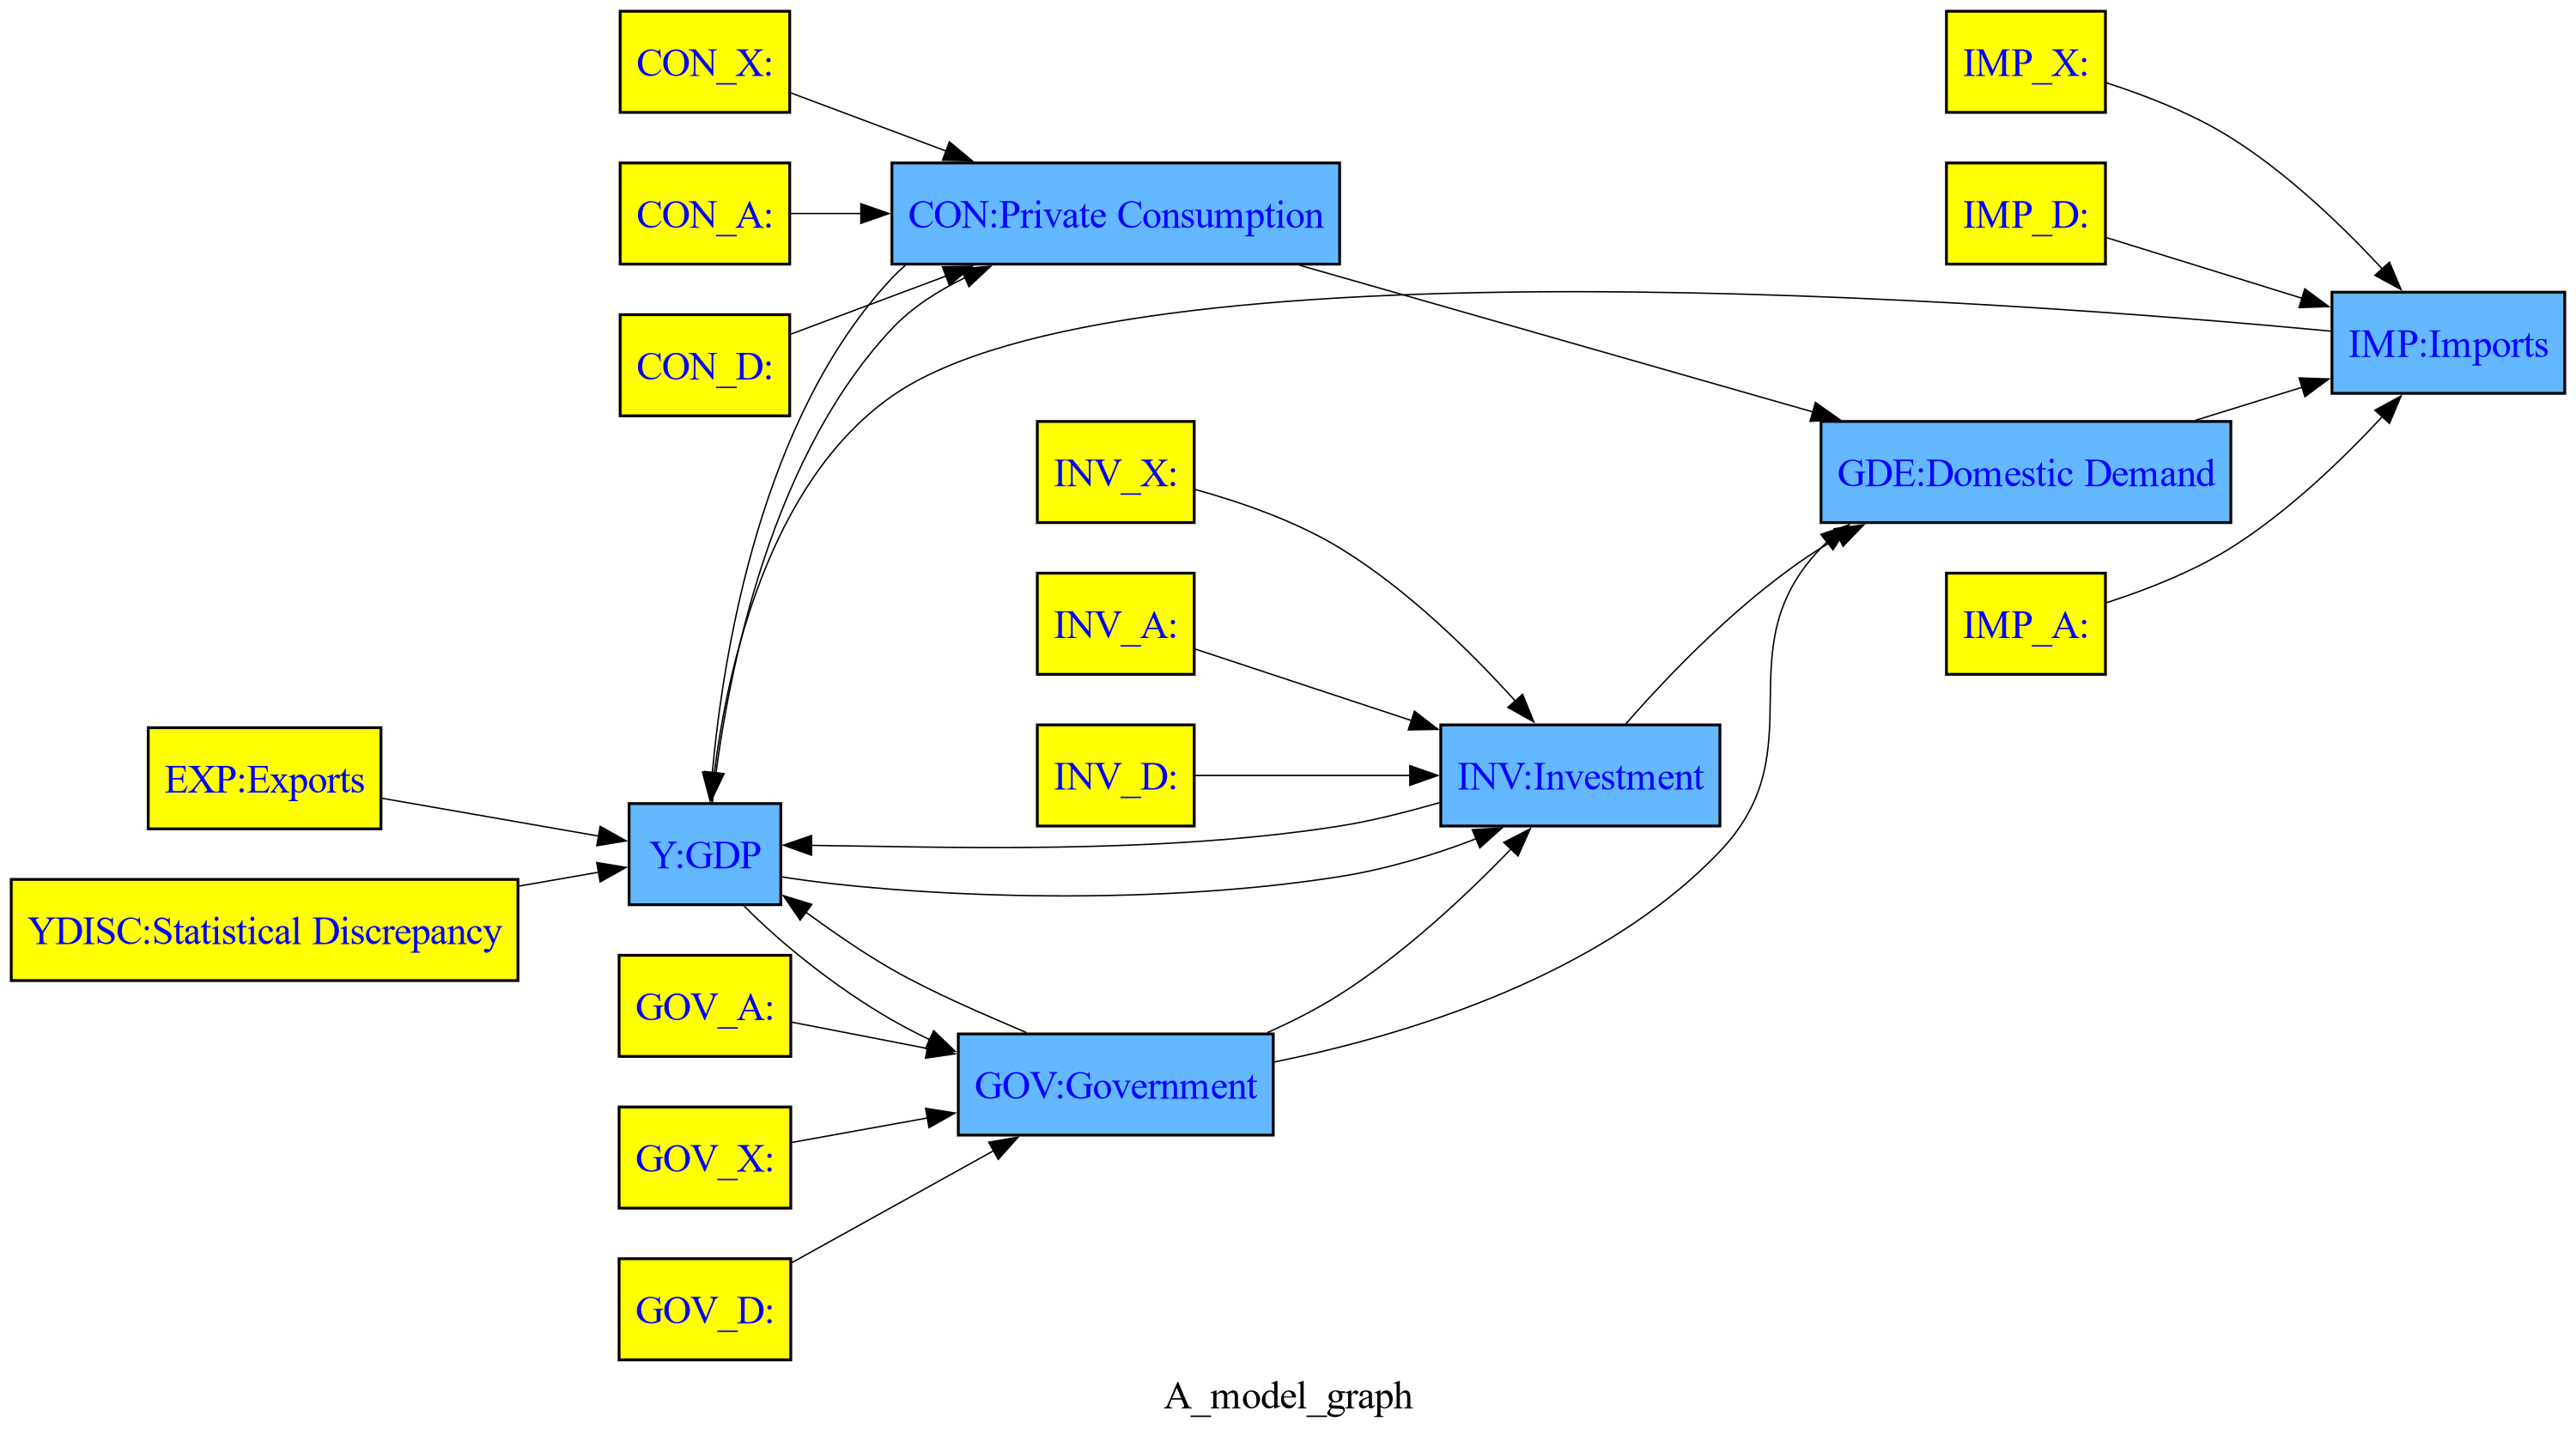

In [27]:
toymodel.drawmodel(png=1, size=(10, 10), lag=0)

The `.clean_model_draw` property for the equations collection is somewhat cleaner, omitting the \_X, \_D, \_A variables.

No minimum feedback order: `k` must be an integer satisfying `0 < k < min(A.shape)`. 


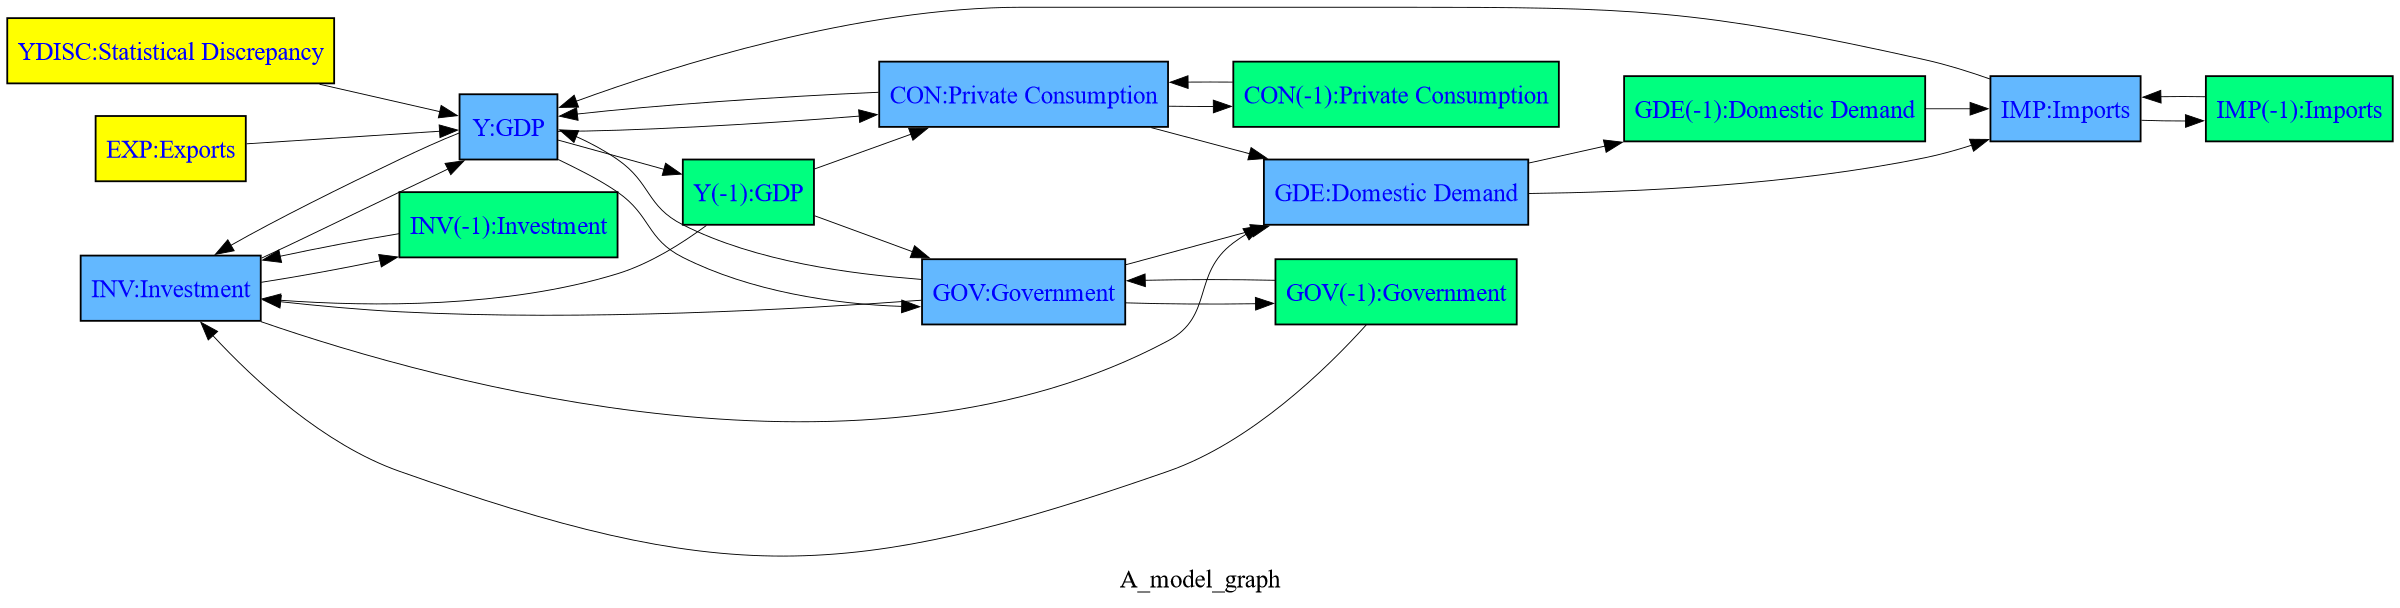

In [28]:
Mtoymodel.clean_model.drawmodel(png=1, size=(8, 8))

the plotadjacency() method displays an adjacency matrix of the model, indicating which variables are functions of which other variables and notably those that exist in a feedback block where the value of one variable is determined by the value of a second, which in turn is directly or inidrectly determined by the valye of the first.

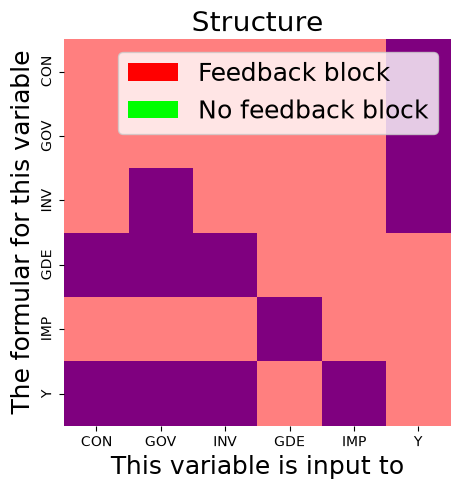

In [29]:
toymodel.plotadjacency() ;

## Scenario analysis

`ModelFlow` includes a wide range of reporting and simulation features, explained in much
greater detail in Burns and Hansen (2025). What follows is a brief illustration of the
syntax needed to run a simulation.

### Registering a baseline with `keep`

`keep=` stores a solution inside the model object rather than only returning it, which is
what makes the comparison below a one-line call. The baseline was registered that way
above.

### Create an alternative scenario

A new scenario is made by taking the baseline dataframe and changing an exogenous — or
exogenized — variable in it.

Here `EXP`, real exports, is exogenous, and is raised by 10 per cent for three years of the
forecast period. The `.upd()` method applies a ModelFlow update expression to a dataframe;
it is explained in more detail in Burns and Hansen (2025).

The shock is put in the forecast rather than in history, because the question being asked
is what happens *relative to the projection*.

In [30]:
exp10 = bline.upd('<2025 2027> exp * 1.1')

Checking the shock before running it is a habit worth keeping: an update expression that
matched nothing, or hit the wrong years, produces a scenario which looks plausible and
answers a different question. Below, the alternative exports as a percentage of baseline
exports — up 10 per cent in 2025, 2026 and 2027, and unchanged elsewhere.

In [31]:
100 * exp10.loc[2020:2030, 'EXP'] / bline.loc[2020:2030, 'EXP']

index
2020    100.0
2021    100.0
2022    100.0
2023    100.0
2024    100.0
2025    110.0
2026    110.0
2027    110.0
2028    100.0
2029    100.0
2030    100.0
Name: EXP, dtype: float64

The model is now solved again with the new dataframe as input, under a second `keep=` name.

In [32]:
result = toymodel(exp10, 2016, 2030, keep='Exports up 10 pct 2025-27')

Because both solutions were kept, comparing them takes no bookkeeping: the model holds
them, and `.rplot()` draws whichever are asked for. `datatype='difpctlevel'` shows each
scenario as a percentage difference from the first.

Displayed on its own, `.rplot()` renders as an interactive widget — good in a live notebook,
but a widget cannot be printed, so it comes out of an export as a line of JSON. The `.show`
property displays the underlying matplotlib figures instead, which survive into the PDF.

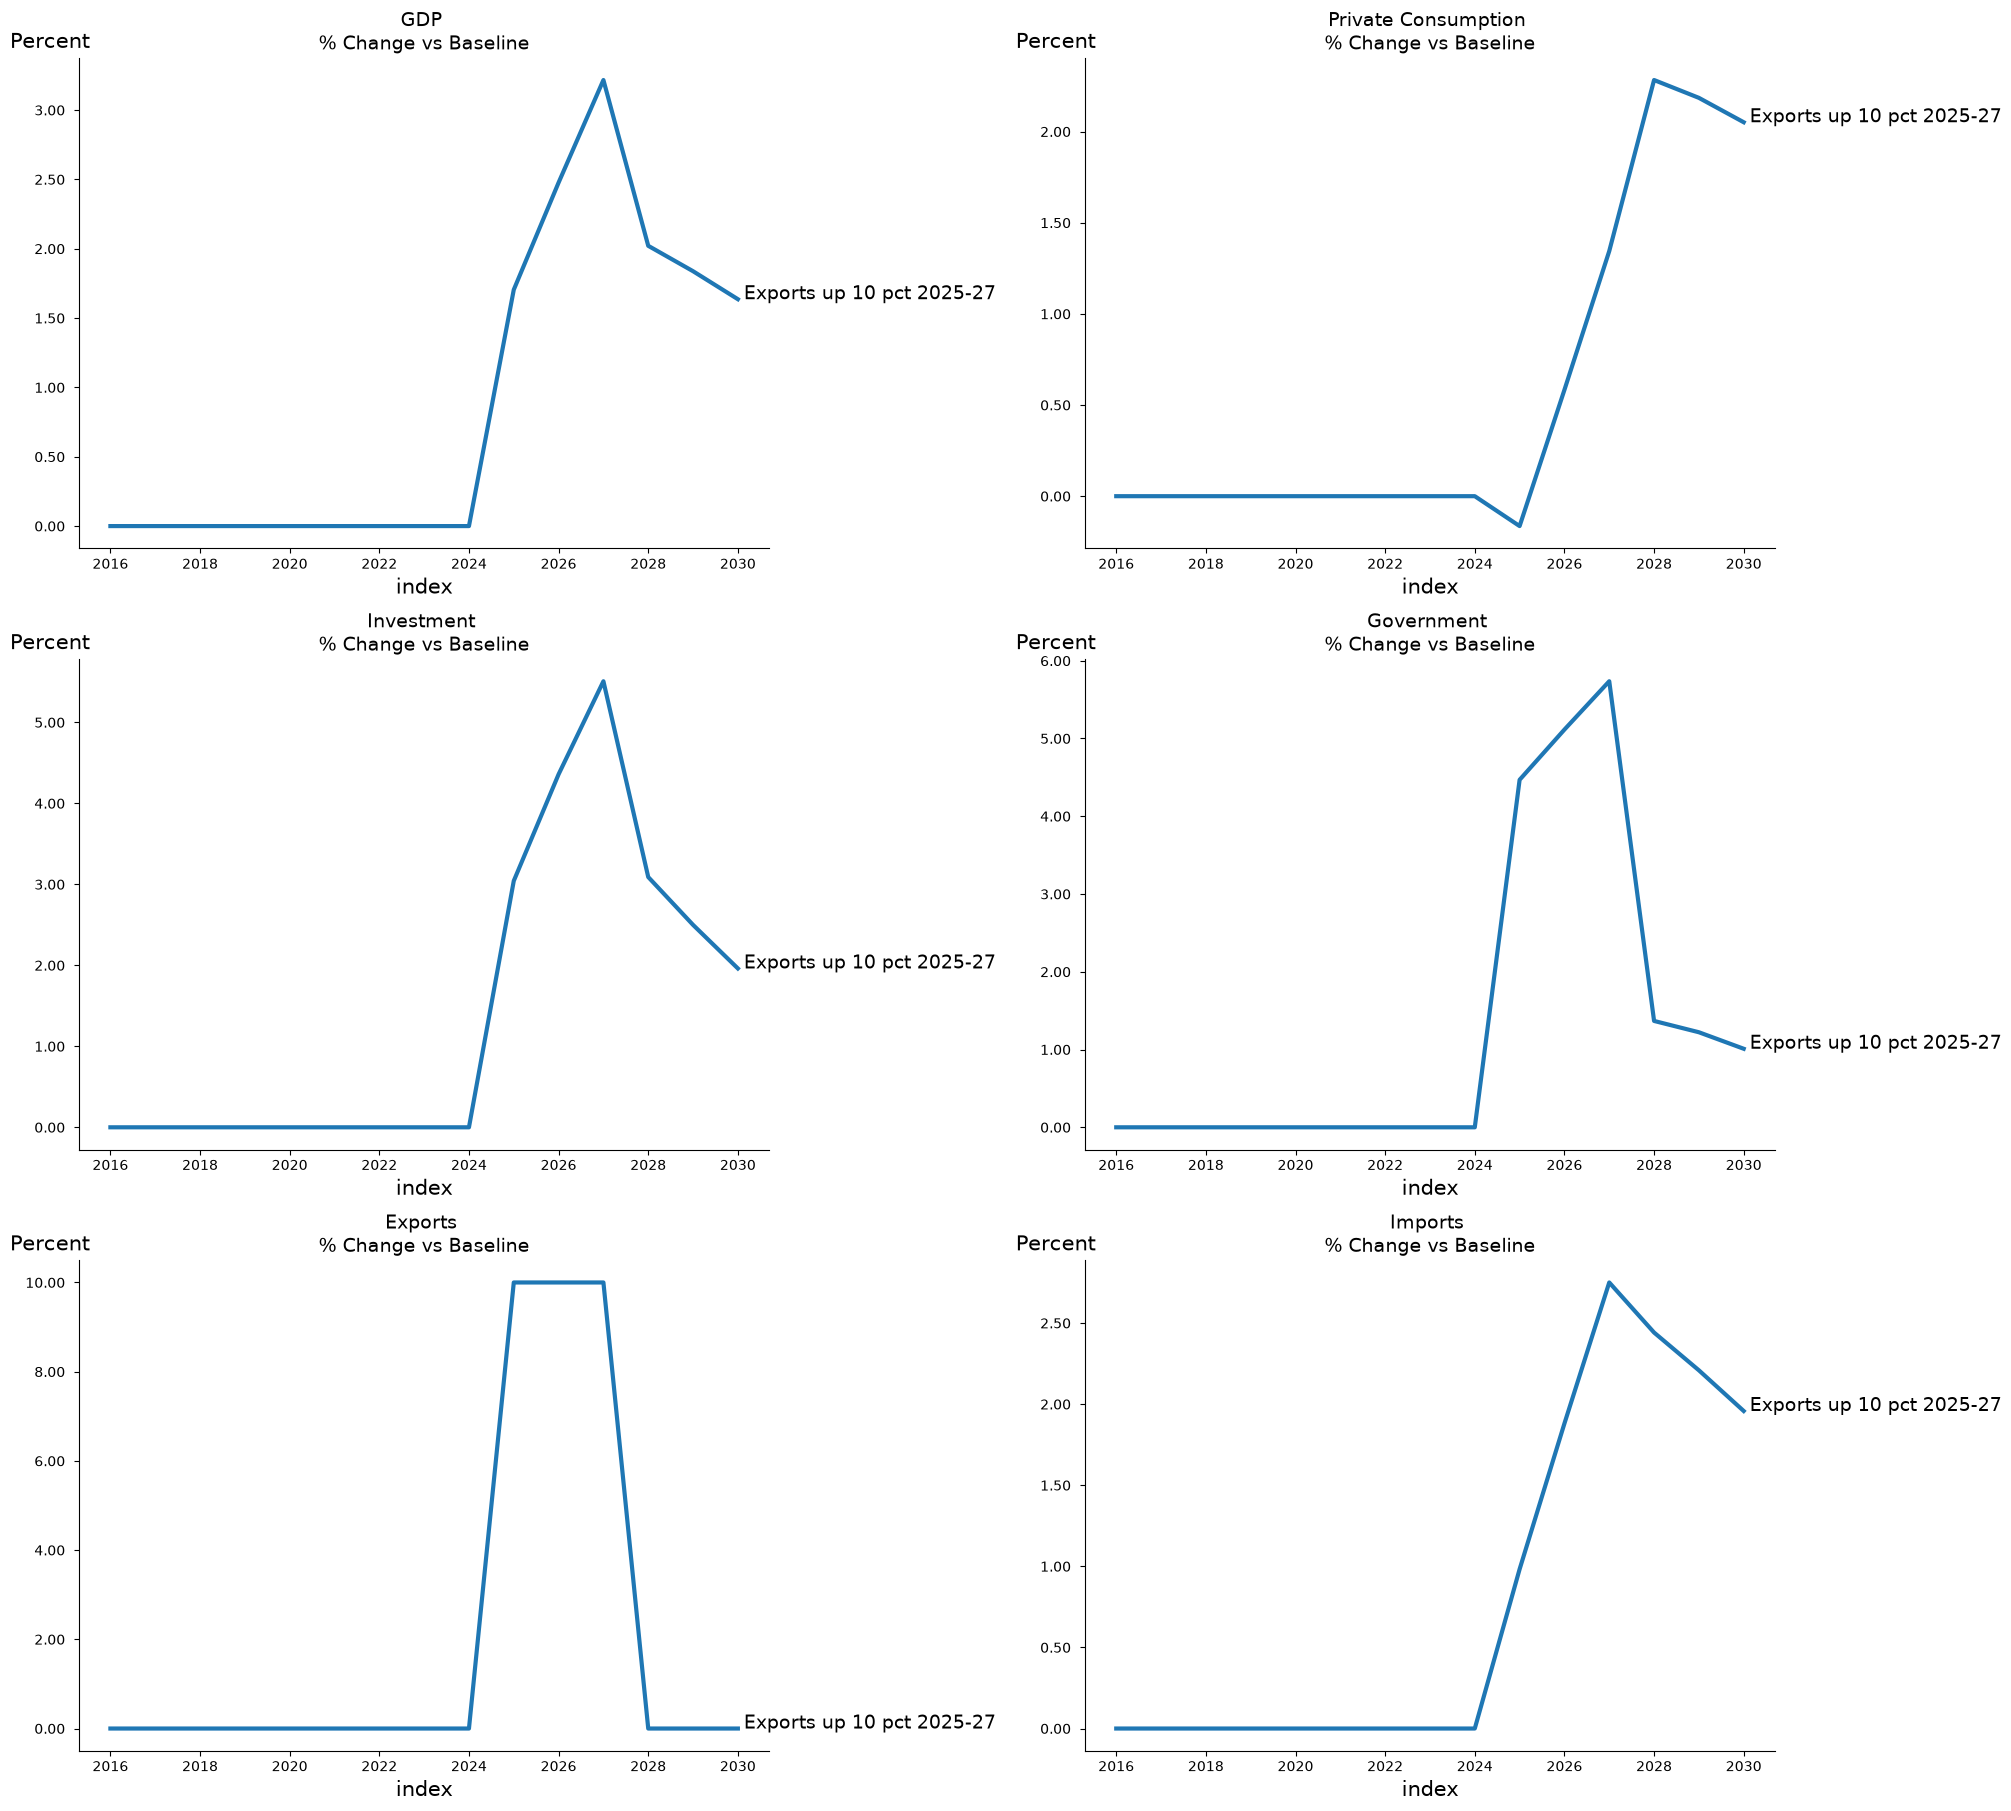

In [33]:
toymodel['y con inv gov exp imp'].rplot(datatype='difpctlevel', samefig=1, by_var=1,
                                        samey=True, legend=False, scenarios='*').show